In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "../data/UK_Accident.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 111
Columns: 33


,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


In [7]:
print("Column Names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

print("\nData Types:")
print(df.dtypes)

Column Names:
1. Unnamed: 0
2. Accident_Index
3. Location_Easting_OSGR
4. Location_Northing_OSGR
5. Longitude
6. Latitude
7. Police_Force
8. Accident_Severity
9. Number_of_Vehicles
10. Number_of_Casualties
11. Date
12. Day_of_Week
13. Time
14. Local_Authority_(District)
15. Local_Authority_(Highway)
16. 1st_Road_Class
17. 1st_Road_Number
18. Road_Type
19. Speed_limit
20. Junction_Control
21. 2nd_Road_Class
22. 2nd_Road_Number
23. Pedestrian_Crossing-Human_Control
24. Pedestrian_Crossing-Physical_Facilities
25. Light_Conditions
26. Weather_Conditions
27. Road_Surface_Conditions
28. Special_Conditions_at_Site
29. Carriageway_Hazards
30. Urban_or_Rural_Area
31. Did_Police_Officer_Attend_Scene_of_Accident
32. LSOA_of_Accident_Location
33. Year

Data Types:
Unnamed: 0                                       int64
Accident_Index                                     str
Location_Easting_OSGR                          float64
Location_Northing_OSGR                         float64
Longitude        

In [8]:
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Carriageway_Hazards           110
Special_Conditions_at_Site    108
Junction_Control               31
LSOA_of_Accident_Location       1
dtype: int64

Duplicate Rows:
0


In [9]:
df_clean = df.copy()

# Remove unnecessary CSV index column
if "Unnamed: 0" in df_clean.columns:
    df_clean.drop(columns=["Unnamed: 0"], inplace=True)

# Remove unique accident ID
if "Accident_Index" in df_clean.columns:
    df_clean.drop(columns=["Accident_Index"], inplace=True)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

display(df_clean.head())

Original shape: (111, 33)
Cleaned shape: (111, 31)


,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,04/01/2005,3,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,05/01/2005,4,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,06/01/2005,5,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,07/01/2005,6,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,10/01/2005,2,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


Accident Severity Counts:
Accident_Severity
2      9
3    102
Name: count, dtype: int64

Accident Severity Percentage:
Accident_Severity
2     8.11
3    91.89
Name: proportion, dtype: float64


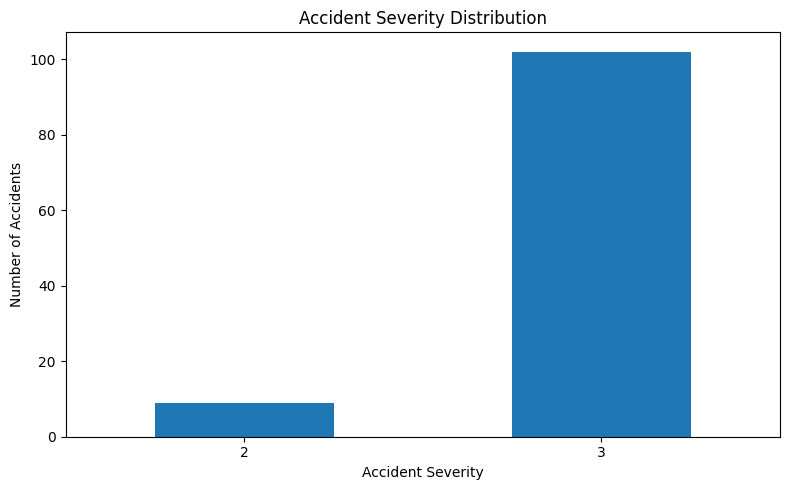

In [10]:
print("Accident Severity Counts:")
severity_counts = df_clean["Accident_Severity"].value_counts().sort_index()

print(severity_counts)

print("\nAccident Severity Percentage:")
severity_percentage = (
    df_clean["Accident_Severity"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(severity_percentage.round(2))

# Visualization
plt.figure(figsize=(8, 5))

severity_counts.plot(kind="bar")

plt.title("Accident Severity Distribution")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()